In [101]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris_data = load_iris()

df = pd.DataFrame(data = iris_data.data, columns = iris_data.feature_names)

In [102]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


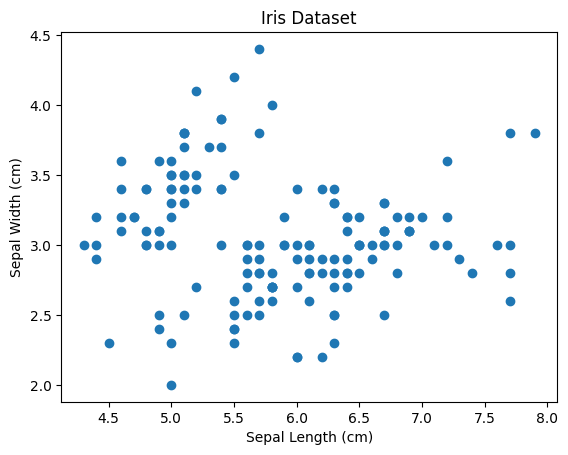

In [103]:
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'])
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Dataset')
plt.show()


In [104]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [105]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

In [106]:
scaled_data = pd.DataFrame(scaled_data, columns = df.columns, index = df.index)
scaled_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,0.222222,0.625000,0.067797,0.041667
1,0.166667,0.416667,0.067797,0.041667
2,0.111111,0.500000,0.050847,0.041667
3,0.083333,0.458333,0.084746,0.041667
4,0.194444,0.666667,0.067797,0.041667
...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667
146,0.555556,0.208333,0.677966,0.750000
147,0.611111,0.416667,0.711864,0.791667
148,0.527778,0.583333,0.745763,0.916667


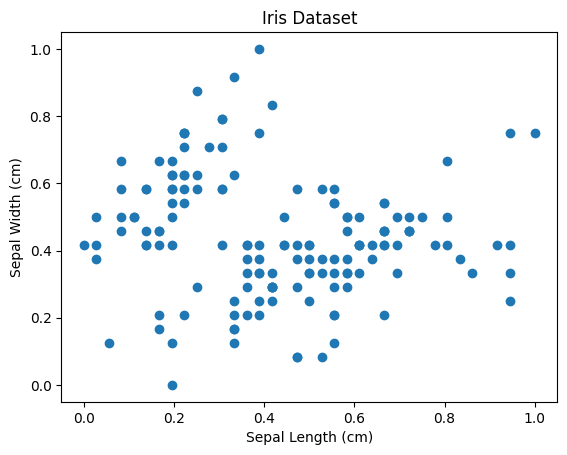

In [107]:
plt.scatter(scaled_data['sepal length (cm)'], scaled_data['sepal width (cm)'])
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Dataset')
plt.show()

In [108]:
inertia = []
rangee = range(1, 11)
for k in rangee:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

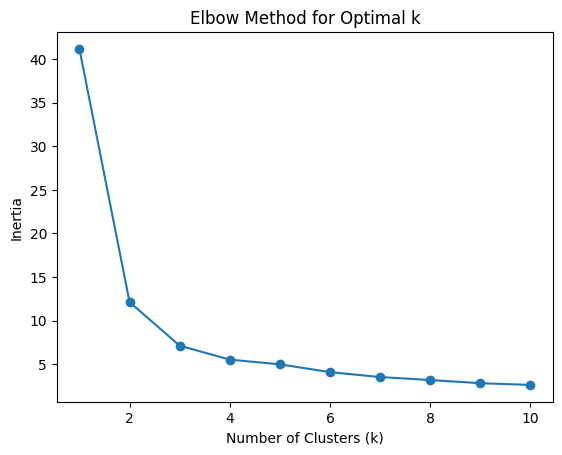

In [109]:
plt.plot(rangee, inertia, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [110]:
from kneed import KneeLocator

knee = KneeLocator(rangee, inertia, curve = "convex", direction = "decreasing")
optimal_k = knee.elbow
optimal_k

np.int64(3)

In [111]:
kmeans = KMeans(n_clusters = optimal_k, random_state = 42, n_init = "auto")

scaled_data['Cluster'] = kmeans.fit_predict(scaled_data)
scaled_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster
0,0.222222,0.625000,0.067797,0.041667,1
1,0.166667,0.416667,0.067797,0.041667,1
2,0.111111,0.500000,0.050847,0.041667,1
3,0.083333,0.458333,0.084746,0.041667,1
4,0.194444,0.666667,0.067797,0.041667,1
...,...,...,...,...,...
145,0.666667,0.416667,0.711864,0.916667,0
146,0.555556,0.208333,0.677966,0.750000,0
147,0.611111,0.416667,0.711864,0.791667,0
148,0.527778,0.583333,0.745763,0.916667,0


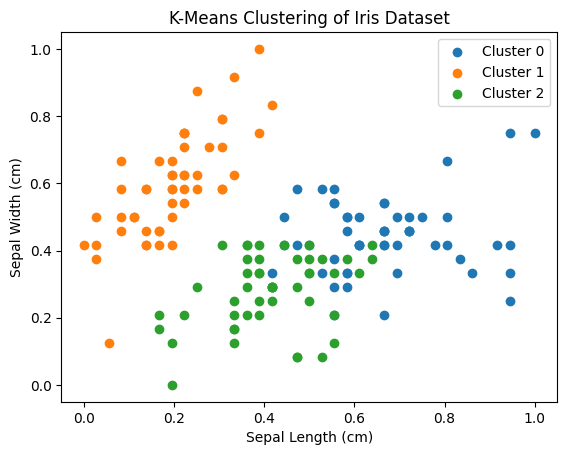

In [112]:
for i in range(optimal_k):
    cluster_data = scaled_data[scaled_data['Cluster'] == i]
    plt.scatter(cluster_data['sepal length (cm)'], cluster_data['sepal width (cm)'], label = f'Cluster {i}')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('K-Means Clustering of Iris Dataset')
plt.legend()
plt.show()

In [113]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    scaled_data.drop('Cluster', axis = 1),
    scaled_data['Cluster']
)
score

0.48292893354301647

In [114]:
df['Target'] = iris_data.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


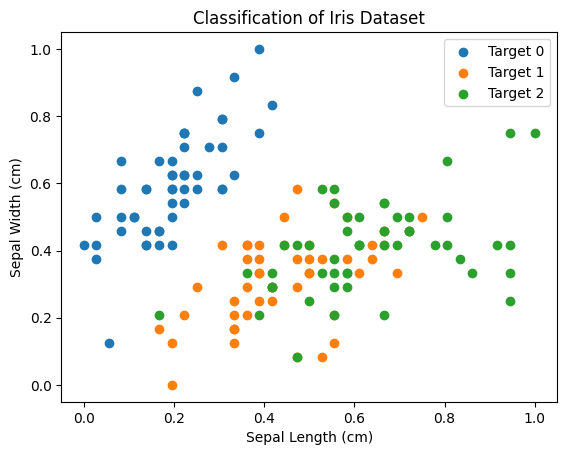

In [115]:
for i in range(len(iris_data.target_names)):
    cluster_data = scaled_data[df['Target'] == i]
    plt.scatter(cluster_data['sepal length (cm)'], cluster_data['sepal width (cm)'], label = f'Target {i}')

plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Classification of Iris Dataset')
plt.legend()
plt.show()

In [116]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score

mapped_labels = {}

for num in range(optimal_k):
    cluster_data = scaled_data[scaled_data['Cluster'] == num]
    mapped_labels[num] = mode(iris_data.target[cluster_data.index], keepdims = True).mode[0]

In [117]:
df['Predicted_Cluster'] = scaled_data['Cluster'].map(mapped_labels)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target,Predicted_Cluster
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,2
146,6.3,2.5,5.0,1.9,2,2
147,6.5,3.0,5.2,2.0,2,2
148,6.2,3.4,5.4,2.3,2,2


In [118]:
acc_score = accuracy_score(df['Target'], df['Predicted_Cluster'])
acc_score

0.88